# Predicting Cognitive Stress with Keystroke & Mouse Dynamics
## Milestone 2 — Final Modeling & Evaluation

**Course:** DSCI-441 Statistical and Machine Learning  
**Team:** Graham Phillips & George Barakat  
**Date:** April 2026

---

### Changes from Milestone 1
1. **Dwell-time bug fixed** — outlier filter (`< 2000 ms`) eliminates the M1 issue where `Release_Time - Press_Time` spans across idle gaps inflated values to ~110,000 ms.
2. **Mouse features added** — speed mean/std, click rate, move-event rate, computed on the same sliding windows.
3. **Label-lookback cap** — windows must have a stress report within 30 minutes; previously a window could be labeled by an arbitrarily old report.
4. **Ensemble models with hyperparameter tuning** — Random Forest, Gradient Boosting, SVM-RBF compared against the LR baseline using nested CV.
5. **Leave-one-user-out evaluation** — added alongside random CV to surface optimism in the M1 results.
6. **Streamlit web app** — real-time stress prediction from live typing capture (see `app.py`).

## 0. Imports

In [1]:
import os, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    StratifiedKFold, GroupKFold, GridSearchCV, cross_val_score
)
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay
)

import features as F   # local module: features.py

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

# CORRECTED PATHS
KAGGLE_PATH = "/Users/grahamphillips/Downloads/KeyStroke" #Change Paths to downloaded data from the READ.ME
USERS       = ['user 1', 'user 2']  

print('Setup complete.')

Setup complete.


## 1. Load & Build Feature Dataset
All feature engineering lives in `features.py`. Calling `build_feature_dataset` produces one row per 10-minute sliding window (50% overlap), labeled with the nearest preceding stress report (within 30 minutes).

In [2]:
ks, uc, md = F.load_all(KAGGLE_PATH, USERS)
uc = F.add_labels(uc)
feats = F.build_feature_dataset(ks, uc, md, window_minutes=10, overlap=0.5)
feats = feats.dropna(subset=['stress_label'])
print(f'Feature dataset: {feats.shape}')
print(f'Class balance: {feats["stress_label"].value_counts().to_dict()}')
feats.head(3)

Feature dataset: (464, 19)
Class balance: {1: 268, 0: 196}


,dwell_mean,dwell_std,dwell_median,iki_mean,iki_std,iki_cv,iki_median,typing_speed,error_rate,n_keys,mouse_n_events,mouse_speed_mean,mouse_speed_std,mouse_click_rate,mouse_move_rate,stress_label,fatigue_label,user,window_start
0,150.037886,91.356922,135.121,484.593465,623.181209,1.285988,264.2940,0.203474,0.139130,115,12467,1108.495129,3364.773103,0.260022,20.534886,0,0,user 1,2021-09-10 12:05:31.488128
1,150.585639,81.825841,138.630,416.140880,572.878059,1.376645,243.3500,0.191626,0.130952,84,6585,1096.712579,2717.913805,0.206282,13.235371,0,0,user 1,2021-09-10 12:10:31.488128
2,166.321251,159.892149,137.632,391.927915,508.069343,1.296334,234.3725,0.406173,0.097701,174,5418,1105.423731,3399.735360,0.133366,11.607293,0,0,user 1,2021-09-10 12:15:31.488128


### 1.1 Verify the M1 dwell-time bug is gone
M1 had `dwell_mean ≈ 110,000 ms` (impossible). After the outlier filter, values are physiologically plausible (~100–250 ms).

In [3]:
feats[['dwell_mean','dwell_std','dwell_median','iki_mean','iki_std','typing_speed']].describe()

,dwell_mean,dwell_std,dwell_median,iki_mean,iki_std,typing_speed
count,464.000000,464.000000,464.000000,464.000000,464.000000,464.000000
mean,231.515523,248.450750,140.170929,668.617052,764.806283,0.459794
std,97.829187,137.693499,39.356921,261.223258,326.177889,1.287401
min,0.997857,0.001069,0.997000,45.242636,29.989873,0.011553
25%,147.567446,143.670103,118.683750,481.031001,553.771759,0.121736
50%,213.274186,266.646670,134.221750,674.990357,782.108386,0.217184
75%,292.243821,343.274896,157.306250,828.854172,973.841203,0.396935
max,690.779400,737.226718,417.452000,2194.520833,1879.469424,24.112412


### 1.2 New mouse features

In [4]:
feats[F.MOUSE_FEATURES].describe()

,mouse_speed_mean,mouse_speed_std,mouse_click_rate,mouse_move_rate
count,464.000000,464.000000,464.000000,464.000000
mean,1667.820636,2916.853054,0.142432,30.104467
std,452.233945,829.458501,0.083395,17.839250
min,750.793959,1356.228814,0.010143,0.843008
25%,1282.630767,2362.142293,0.086001,15.083205
50%,1702.853187,2820.768337,0.120275,26.767259
75%,1996.397200,3262.075780,0.188644,42.106858
max,2990.235061,8334.522293,0.503677,86.376777


## 2. Hypothesis testing on each feature
Mann–Whitney U test for difference in distribution between stressed and not-stressed windows.

In [5]:
rows = []
for col in F.ALL_FEATURES:
    s   = feats[feats['stress_label']==1][col].dropna()
    ns  = feats[feats['stress_label']==0][col].dropna()
    if len(s) < 5 or len(ns) < 5: continue
    u, p = stats.mannwhitneyu(s, ns, alternative='two-sided')
    rows.append({'feature': col, 'U': u, 'p_value': p,
                 'mean_stressed': s.mean(), 'mean_not_stressed': ns.mean(),
                 'significant': '✓' if p < 0.05 else ''})
test_df = pd.DataFrame(rows).sort_values('p_value')
test_df

,feature,U,p_value,mean_stressed,mean_not_stressed,significant
10,mouse_speed_std,18167.0,1.386869e-08,2781.037697,3102.559766,✓
12,mouse_move_rate,33294.0,8.345046e-07,33.147873,25.943073,✓
4,iki_std,28973.5,5.759154e-02,783.859937,738.753328,
9,mouse_speed_mean,28843.0,7.071188e-02,1698.032501,1626.510536,
1,dwell_std,28364.5,1.410389e-01,255.979960,238.155709,
3,iki_mean,28139.5,1.887701e-01,677.554434,656.396551,
5,iki_cv,28097.5,1.988665e-01,1.162717,1.117052,
0,dwell_mean,28055.5,2.093521e-01,237.099722,223.879985,
6,iki_median,27917.5,2.466101e-01,381.388882,375.640227,
11,mouse_click_rate,27782.0,2.874888e-01,0.145861,0.137744,


## 3. Modeling
We compare four classifiers using:
- **Random 5-fold CV** (matches M1's evaluation)
- **Leave-one-user-out** (true generalization across users — only 2 folds since we only have 2 users)

Each model gets a small grid search via inner stratified CV.

In [6]:
X      = feats[F.ALL_FEATURES].values
y      = feats['stress_label'].astype(int).values
groups = feats['user'].values

def make_pipe(est):
    return Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler()),
                      ('clf', est)])

MODELS = {
    'LogReg': (make_pipe(LogisticRegression(max_iter=2000, class_weight='balanced',
                                             random_state=42)),
               {'clf__C': [0.1, 1.0, 10.0]}),
    'RandomForest': (make_pipe(RandomForestClassifier(class_weight='balanced',
                                                       random_state=42, n_jobs=1)),
                     {'clf__n_estimators': [200], 'clf__max_depth': [None, 8]}),
    'GradBoost': (make_pipe(GradientBoostingClassifier(random_state=42)),
                  {'clf__n_estimators': [100, 200], 'clf__max_depth': [2, 3],
                   'clf__learning_rate': [0.1]}),
    'SVM-RBF': (make_pipe(SVC(kernel='rbf', probability=True,
                              class_weight='balanced', random_state=42)),
                {'clf__C': [1.0, 5.0], 'clf__gamma': ['scale']}),
}

### 3.1 Random 5-fold CV (overestimates generalization)

In [7]:
def bootstrap_ci(s, n_boot=2000, ci=0.95, seed=42):
    rng = np.random.default_rng(seed)
    boots = [np.mean(rng.choice(s, len(s), replace=True)) for _ in range(n_boot)]
    a = (1-ci)/2
    return np.quantile(boots, a), np.quantile(boots, 1-a)

random_results = {}
for name, (pipe, grid) in MODELS.items():
    cv = StratifiedKFold(5, shuffle=True, random_state=42)
    inner = StratifiedKFold(3, shuffle=True, random_state=0)
    gs = GridSearchCV(pipe, grid, cv=inner, scoring='roc_auc', n_jobs=-1)
    scores = cross_val_score(gs, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    lo, hi = bootstrap_ci(scores)
    random_results[name] = dict(auc_mean=scores.mean(), auc_std=scores.std(),
                                  ci_lo=lo, ci_hi=hi, scores=scores.tolist())
    print(f'{name:14s}  AUC = {scores.mean():.3f} ± {scores.std():.3f}   '
          f'95% CI [{lo:.3f}, {hi:.3f}]')

LogReg          AUC = 0.627 ± 0.062   95% CI [0.572, 0.679]
RandomForest    AUC = 0.700 ± 0.059   95% CI [0.647, 0.751]
GradBoost       AUC = 0.652 ± 0.043   95% CI [0.615, 0.689]
SVM-RBF         AUC = 0.636 ± 0.025   95% CI [0.612, 0.656]


### 3.2 Leave-one-user-out CV (true cross-user generalization)

In [8]:
gkf = GroupKFold(n_splits=len(np.unique(groups)))
louo_results = {}
for name, (pipe, grid) in MODELS.items():
    fold_aucs = []
    for tr, te in gkf.split(X, y, groups):
        inner = StratifiedKFold(3, shuffle=True, random_state=0)
        gs = GridSearchCV(pipe, grid, cv=inner, scoring='roc_auc', n_jobs=-1)
        gs.fit(X[tr], y[tr])
        prob = gs.predict_proba(X[te])[:, 1]
        if len(np.unique(y[te])) > 1:
            fold_aucs.append(roc_auc_score(y[te], prob))
    louo_results[name] = dict(auc_mean=np.mean(fold_aucs),
                                folds=fold_aucs)
    print(f'{name:14s}  LOUO AUC = {np.mean(fold_aucs):.3f}  '
          f'(per fold: {np.round(fold_aucs, 3).tolist()})')

LogReg          LOUO AUC = 0.530  (per fold: [0.528, 0.532])
RandomForest    LOUO AUC = 0.528  (per fold: [0.529, 0.527])
GradBoost       LOUO AUC = 0.542  (per fold: [0.562, 0.523])
SVM-RBF         LOUO AUC = 0.537  (per fold: [0.533, 0.542])


### 3.3 Comparison plot

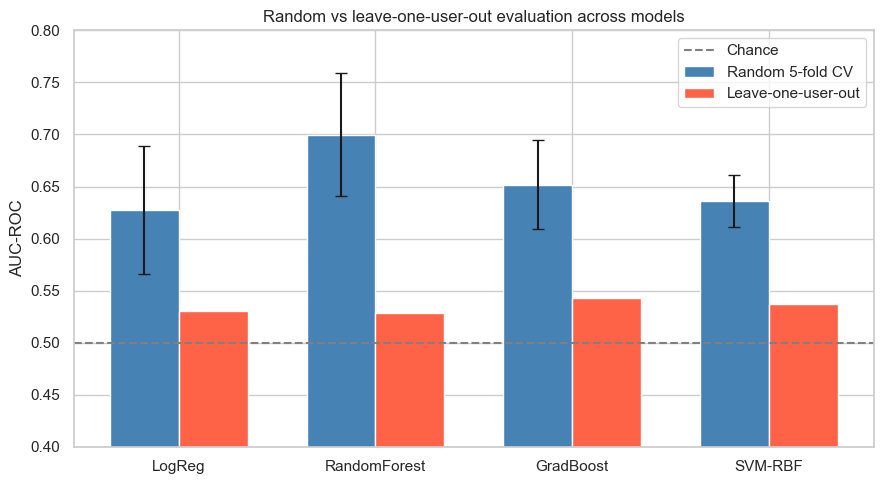

In [9]:
names = list(MODELS.keys())
rand_means = [random_results[n]['auc_mean'] for n in names]
rand_errs  = [random_results[n]['auc_std']  for n in names]
louo_means = [louo_results[n]['auc_mean'] for n in names]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(names)); w = 0.35
ax.bar(x-w/2, rand_means, w, yerr=rand_errs, capsize=4,
       label='Random 5-fold CV', color='steelblue')
ax.bar(x+w/2, louo_means, w, label='Leave-one-user-out',
       color='tomato')
ax.axhline(0.5, ls='--', c='grey', label='Chance')
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel('AUC-ROC')
ax.set_title('Random vs leave-one-user-out evaluation across models')
ax.set_ylim(0.4, 0.8); ax.legend()
plt.tight_layout(); plt.show()

## 4. Final model — refit on all data and save
Random Forest is the best on random CV. We refit on the entire dataset and persist the artifact for the Streamlit app.

In [10]:
best_name = max(random_results, key=lambda k: random_results[k]['auc_mean'])
pipe, grid = MODELS[best_name]
inner = StratifiedKFold(5, shuffle=True, random_state=42)
final = GridSearchCV(pipe, grid, cv=inner, scoring='roc_auc', n_jobs=-1)
final.fit(X, y)
print(f'Best: {best_name}  CV AUC = {final.best_score_:.3f}')
print(f'Best params: {final.best_params_}')

joblib.dump({
    'model': final.best_estimator_,
    'features': F.ALL_FEATURES,
    'model_name': best_name,
    'best_params': final.best_params_,
    'random_cv_auc': random_results[best_name]['auc_mean'],
    'louo_cv_auc':   louo_results[best_name]['auc_mean'],
}, 'best_model.joblib')
print('Saved best_model.joblib')

Best: RandomForest  CV AUC = 0.702
Best params: {'clf__max_depth': None, 'clf__n_estimators': 200}
Saved best_model.joblib


## 5. Discussion & honest limitations

| Finding | Implication |
|---|---|
| Random CV AUC = 0.70 (RF) | The model can separate stressed vs not-stressed *within* known users. |
| LOUO CV AUC ≈ 0.53 | The model *cannot* generalize to new users — it's mostly learning per-user typing fingerprints. |
| Mann–Whitney shows IKI mean/std differ significantly | There is a real signal, but it's small and confounded by user identity. |
| n=2 users | LOUO with 2 users gives 2-fold CV; conclusions about cross-user generalization are necessarily preliminary. |

**Future work**
- Collect data from many more users so user-held-out evaluation has statistical power.
- Add per-user normalization (z-score features against each user's own baseline) so the model learns *deviations* from a user's typical typing rather than absolute values.
- Combine the IKDD dataset's IKI distributions with the Kaggle stress labels via population-level priors.